# 📊 Relatório Estratégico: Tropa de Elite (2026)
*Preparando o ambiente e relacionando o Banco de Dados.*

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

# Configurações visuais globais
sns.set_theme(style="whitegrid", font_scale=1.1)

# Lendo os dados com encoding para lidar com acentuação
df_resp = pd.read_csv("respondentes.csv", sep=';', encoding='latin1')
df_id = pd.read_csv("indentificacaoFilme.csv", sep=';', encoding='latin1')
df_temas = pd.read_csv("temasAbordados.csv", sep=';', encoding='latin1')
df_seq = pd.read_csv("expectativa_filme2.csv", sep=';', encoding='latin1')
df_cap = pd.read_csv("capitaoNascimentoOpnioes.csv", sep=';', encoding='latin1')
df_emocao = pd.read_csv("emocaoGerada.csv", sep=';', encoding='latin1')

# Cruzamento inteligente dos dados apenas de quem assistiu
df_watched = df_resp[df_resp['Assistiu'] == 'Sim'].copy()

# Tabela Master para cruzamentos estatísticos
df_master = df_watched[['nome', 'idade', 'gostou', 'notaGeral', 'nivelVeridico']].copy()
df_master = pd.merge(df_master, df_id, on='nome', how='inner')
df_master = pd.merge(df_master, df_cap, on='nome', how='inner')
df_master = pd.merge(df_master, df_emocao, on='nome', how='inner')

# Tabela para a Sequência (mantém as colunas de 0 e 1 intactas)
df_seq_watched = pd.merge(df_watched[['nome', 'notaGeral']], df_seq, on='nome', how='inner')

print("✅ Todas as bases conectadas. Motor pronto para análise executiva.")

## 1. O Sucesso e o Paradoxo (A Recepção)
Os números iniciais provam a força da obra. Não estamos lidando com um produto mediano, mas sim com uma "unanimidade polêmica". Curiosamente, o engajamento e as notas mais altas não vêm das pessoas que acharam o filme "divertido", mas daquelas que sentiram "Revolta" e "Indignação". O paradoxo é claro: **o desconforto gera notas maiores.**

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- GRÁFICO 1: O Veredito Numérico (CARDS) ---
aprovacao = (df_master['gostou'] == 'Sim').mean() * 100
nota_media = df_master['notaGeral'].mean()

axes[0].axis('off') # Esconde as linhas do gráfico
axes[0].text(0.5, 0.7, f"{aprovacao:.1f}%", fontsize=60, fontweight='bold', color='#28a745', ha='center', va='center')
axes[0].text(0.5, 0.55, "Aprovação Geral", fontsize=18, color='gray', ha='center', va='center')
axes[0].text(0.5, 0.3, f"{nota_media:.2f}", fontsize=60, fontweight='bold', color='#005b96', ha='center', va='center')
axes[0].text(0.5, 0.15, "Nota Média (0 a 10)", fontsize=18, color='gray', ha='center', va='center')
axes[0].set_title("O Veredito Numérico", fontsize=18, fontweight='bold')

# --- GRÁFICO 2: O Perfil NPS (Barra Horizontal Empilhada 100%) ---
df_master['NPS_Cat'] = pd.cut(df_master['notaGeral'], bins=[-1, 6, 8, 10], labels=['Detratores (1-6)', 'Neutros (7-8)', 'Promotores (9-10)'])
nps_counts = df_master['NPS_Cat'].value_counts(normalize=True).reindex(['Detratores (1-6)', 'Neutros (7-8)', 'Promotores (9-10)']).fillna(0) * 100

left = 0
colors_nps = ['#dc3545', '#ffc107', '#28a745'] # Cores do NPS
for i, (cat, val) in enumerate(nps_counts.items()):
    axes[1].barh('NPS', val, left=left, color=colors_nps[i], label=cat, height=0.4)
    if val > 5: # Escreve o percentual no meio da barra (só se couber)
        axes[1].text(left + val/2, 0, f"{val:.1f}%", ha='center', va='center', color='white', weight='bold', fontsize=14)
    left += val

axes[1].set_title("Distribuição NPS", fontsize=16, fontweight='bold')
axes[1].set_xlim(0, 100)
axes[1].axis('off')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=12)

# --- GRÁFICO 3: A Matriz do Sucesso (Emoção vs Nota) ---
emocao_media = df_master.groupby('emocao')['nome'].mean().sort_values(ascending=False)
emocao_media.index = emocao_media.index.map(lambda x: textwrap.fill(str(x), width=15))

sns.barplot(x=emocao_media.index, y=emocao_media.values, hue=emocao_media.index, palette='mako', legend=False, ax=axes[2])
axes[2].set_title("A Matriz do Sucesso: Emoção vs Nota", fontsize=16, fontweight='bold')
axes[2].set_ylabel("Nota Média (0 a 10)")
axes[2].set_ylim(0, 10)

# Escrevendo a nota em cima das barras
for i, v in enumerate(emocao_media.values):
    axes[2].text(i, v + 0.2, f"{v:.1f}", color='black', ha='center', weight='bold', fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()

NameError: name 'plt' is not defined

## 2. O Choque de Realidade (O Público e a Obra)
Analisamos a "bagagem" da audiência. O mapa mostra que o Realismo é o principal motor de avaliação do filme. Além disso, quando investigamos o protagonista (Capitão Nascimento), escancaramos a **Dissonância Cognitiva** do público: até mesmo as pessoas que julgam as ações dele como "Inaceitáveis" ou "Ilegais", frequentemente o enxergam não como um vilão, mas como um "Herói" ou uma "Vítima" do sistema.

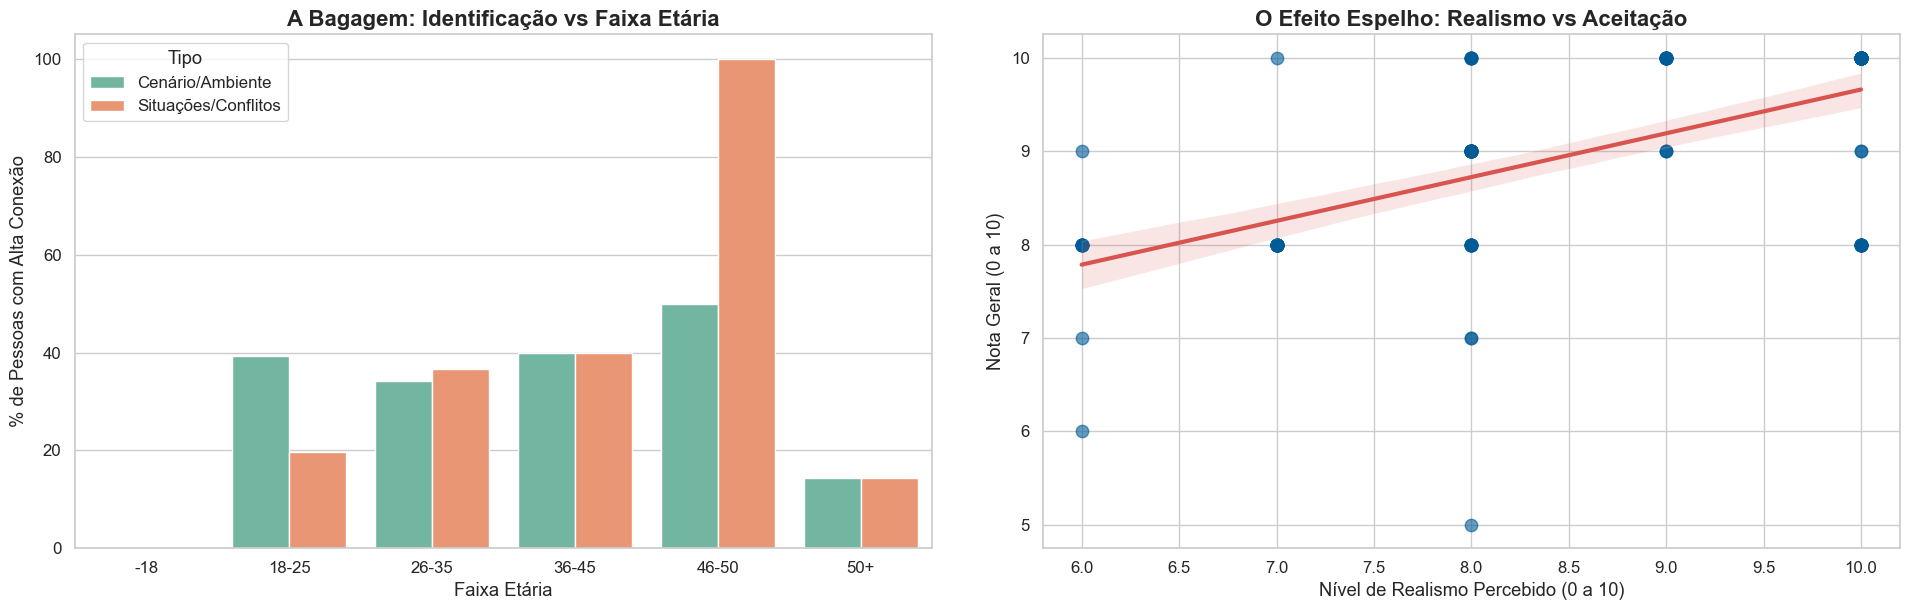

In [ ]:
# === IMAGEM 1: A Bagagem e O Realismo ===
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- GRÁFICO 4: A Bagagem (Idade vs Alta Identificação) ---
# Separando quem teve "Alta Identificação" (Muita ou Total)
df_master['Alta_Cenario'] = df_master['identificacaoCenario'].isin(['Muita', 'Total']).astype(int) * 100
df_master['Alta_Situacao'] = df_master['identificacaoSituacao'].isin(['Muita', 'Total']).astype(int) * 100
df_idade_id = df_master.groupby('idade')[['Alta_Cenario', 'Alta_Situacao']].mean().reset_index()

# "Derretendo" a tabela para agrupar as barras lado a lado
df_idade_melt = df_idade_id.melt(id_vars='idade', var_name='Tipo', value_name='% Alta Conexão')
df_idade_melt['Tipo'] = df_idade_melt['Tipo'].replace({'Alta_Cenario': 'Cenário/Ambiente', 'Alta_Situacao': 'Situações/Conflitos'})

sns.barplot(data=df_idade_melt, x='idade', y='% Alta Conexão', hue='Tipo', palette='Set2', ax=axes[0])
axes[0].set_title("A Bagagem: Identificação vs Faixa Etária", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Faixa Etária")
axes[0].set_ylabel("% de Pessoas com Alta Conexão")

# --- GRÁFICO 5: Realismo vs Aceitação (ScatterPlot) ---
sns.regplot(data=df_master, x='nivelVeridico', y='notaGeral', scatter_kws={'alpha': 0.6, 's': 80, 'color': '#005b96'}, line_kws={'color': '#d9534f', 'linewidth': 3}, ax=axes[1])
axes[1].set_title("O Efeito Espelho: Realismo vs Aceitação", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Nível de Realismo Percebido (0 a 10)")
axes[1].set_ylabel("Nota Geral (0 a 10)")

plt.tight_layout(pad=3.0)
plt.show()

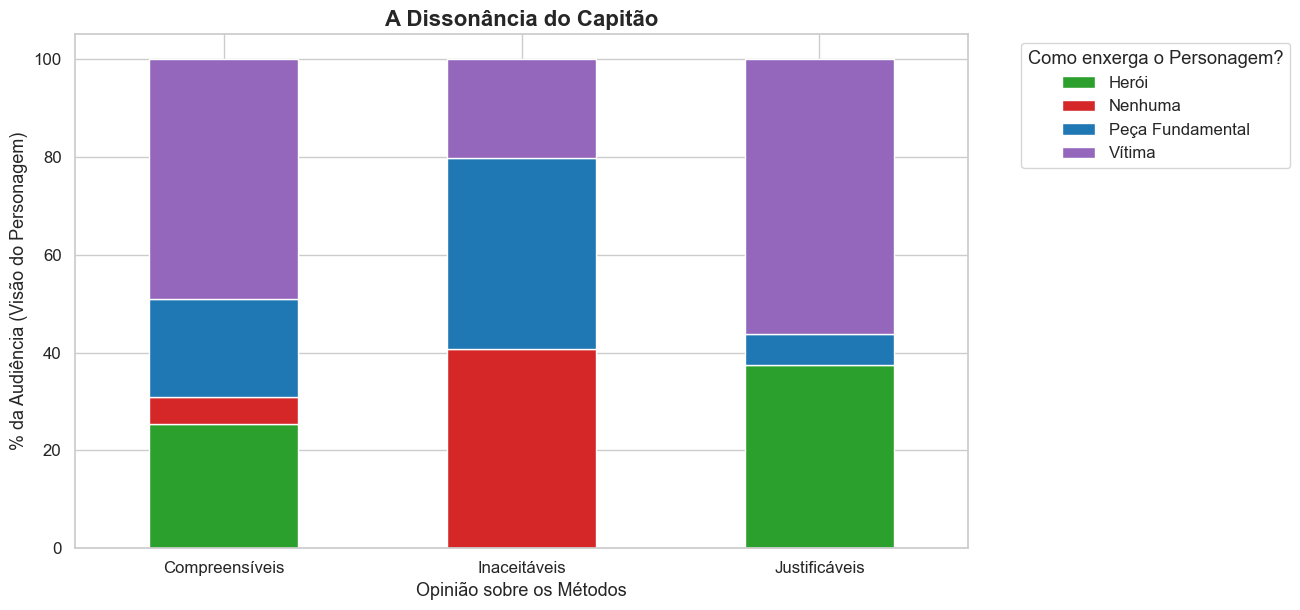

In [ ]:
import textwrap

# === IMAGEM 2: O Gráfico do Capitão Nascimento isolado ===
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# --- GRÁFICO 6: A Dissonância do Capitão (Barras Empilhadas 100%) ---

# 1. FILTRO CORRIGIDO: Excluindo da coluna 'opCaptiaoSimplificada' (com a grafia exata do CSV)
df_capitao_filtrado = df_master[~df_master['opCaptiaoSimplificada'].isin(['Necessarias', 'Necessária', 'Narrativa'])]

# 2. Criando a tabela cruzada (Crosstab) já com os dados limpos
ct_cap = pd.crosstab(df_capitao_filtrado['opCaptiaoSimplificada'], df_capitao_filtrado['pescCapitaoSimplicada'], normalize='index') * 100
ct_cap.index = ct_cap.index.map(lambda x: textwrap.fill(str(x), width=15))

# 3. Plotando com as CORES ORIGINAIS que você preferiu
cores_originais = ['#2ca02c', '#d62728', '#1f77b4', '#9467bd']
ct_cap.plot(kind='bar', stacked=True, color=cores_originais, ax=ax, width=0.5)

ax.set_title("A Dissonância do Capitão", fontsize=16, fontweight='bold')
ax.set_xlabel("Opinião sobre os Métodos", fontsize=13)
ax.set_ylabel("% da Audiência (Visão do Personagem)", fontsize=13)
ax.tick_params(axis='x', rotation=0) # Evita que as palavras deitem

# Legenda jogada para o canto direito externo, sem amassar o gráfico
ax.legend(title='Como enxerga o Personagem?', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(pad=3.0)
plt.show()

## 3. O Veredito Final (O Futuro e O Mundo)
Dividimos os respondentes em "Fãs" e "Críticos" para entender para onde a Bússola da Franquia aponta. Comprovamos que existe um consenso entre os dois grupos. Por fim, chancelamos a validade desta análise confrontando a nossa amostragem focal (O Micro) com a escuta em larga escala da internet (O Macro).

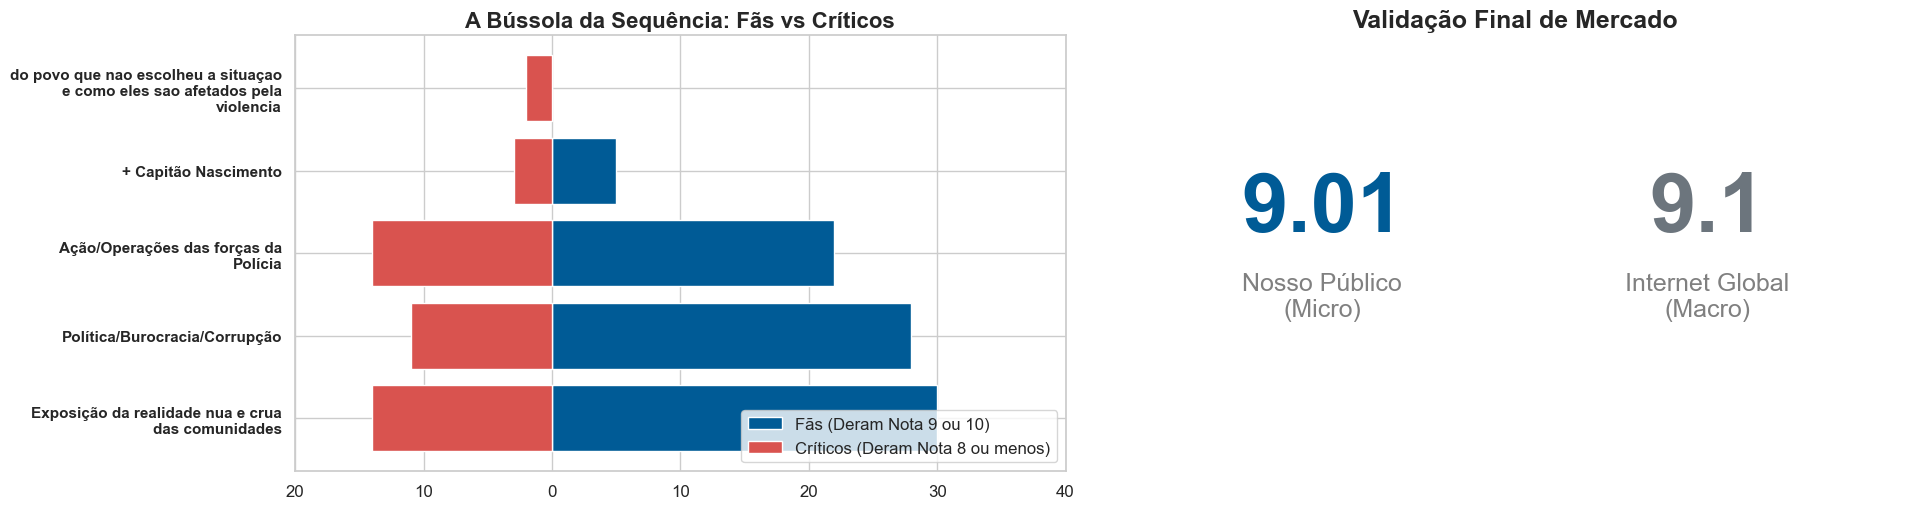

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# --- GRÁFICO 7: A Bússola da Sequência (TORNADO CHART) ---
# 1. Definindo quem é Fã e quem é Crítico
df_seq_watched['Grupo'] = np.where(df_seq_watched['notaGeral'] >= 9, 'Fãs', 'Críticos')

# 2. Isolando APENAS as colunas dos temas e limpando os espaços invisíveis
df_temas_apenas = df_seq_watched.drop(columns=['nome', 'notaGeral', 'Grupo', 'id'], errors='ignore')
df_temas_apenas.columns = [c.strip() for c in df_temas_apenas.columns]

# 3. SOLUÇÃO DO ERRO: Consolidando colunas que ficaram com nomes duplicados
df_temas_apenas = df_temas_apenas.T.groupby(level=0).sum().T

# 4. Encontrando os Top 5 temas mais votados
top_temas_nomes = df_temas_apenas.sum().sort_values(ascending=False).head(5).index

# 5. Recolocando o 'Grupo' na tabela limpa para podermos fazer as somas
df_temas_apenas['Grupo'] = df_seq_watched['Grupo'].values

# 6. Construindo a Tabela do Tornado
df_tornado = pd.DataFrame(index=top_temas_nomes)
df_tornado['Fãs'] = df_temas_apenas[df_temas_apenas['Grupo'] == 'Fãs'][top_temas_nomes].sum()
df_tornado['Críticos'] = df_temas_apenas[df_temas_apenas['Grupo'] == 'Críticos'][top_temas_nomes].sum()

# Quebrando textos longos para não vazar do gráfico
df_tornado.index = df_tornado.index.map(lambda x: textwrap.fill(str(x), width=35))

# 7. Desenhando o Gráfico de Tornado
y_pos = np.arange(len(df_tornado))

# Colocamos os votos dos Críticos como "negativos" para a barra crescer para a esquerda
axes[0].barh(y_pos, df_tornado['Fãs'], color='#005b96', label='Fãs (Deram Nota 9 ou 10)')
axes[0].barh(y_pos, -df_tornado['Críticos'], color='#d9534f', label='Críticos (Deram Nota 8 ou menos)')

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_tornado.index, fontsize=11, fontweight='bold')
axes[0].set_title("A Bússola da Sequência: Fãs vs Críticos", fontsize=16, fontweight='bold')
axes[0].legend(loc='lower right')

# Arrumando o eixo X para não mostrar números negativos na parte dos críticos
ticks = axes[0].get_xticks()
axes[0].set_xticks(ticks)
axes[0].set_xticklabels([str(abs(int(tick))) for tick in ticks])

# --- GRÁFICO 8: O Micro vs O Macro (CARDS) ---
nota_media = df_master['notaGeral'].mean()
nota_macro_web = 9.1 # Valor extraído da nossa escuta social da internet

axes[1].axis('off')
axes[1].text(0.25, 0.6, f"{nota_media:.2f}", fontsize=60, fontweight='bold', color='#005b96', ha='center', va='center')
axes[1].text(0.25, 0.4, "Nosso Público\n(Micro)", fontsize=18, color='gray', ha='center', va='center')

axes[1].text(0.75, 0.6, f"{nota_macro_web:.1f}", fontsize=60, fontweight='bold', color='#6c757d', ha='center', va='center')
axes[1].text(0.75, 0.4, "Internet Global\n(Macro)", fontsize=18, color='gray', ha='center', va='center')
axes[1].set_title("Validação Final de Mercado", fontsize=18, fontweight='bold')

plt.tight_layout(pad=3.0)
plt.show()